In [1]:
import cProfile
import pstats


import matplotlib.pyplot as plt
import numpy as np
import tqdm
from matplotlib.colors import LogNorm

from xarray_profile import SingleInterpolation, TripleInterpolation, Data


In [2]:

chunk_coverages = np.linspace(0.05, 0.95, 10)
n_particles = [10**k for k in range(0, 8)]
functions = [SingleInterpolation, TripleInterpolation]
total_time = np.zeros((len(chunk_coverages), len(n_particles), len(functions)))

for i, c in enumerate(tqdm.tqdm(chunk_coverages, desc="Chunk Coverages")):
    for j, n in enumerate(n_particles):
        data = Data(  # ~24Gb uncompressed
            {"store": "datasets/ds_2d_left_agrid_small.zarr", "consolidated": False},
            n_particles=n,
            chunk_coverage=c,
            use_zarr_array=True,
        )
        data.within_ctx = None

        for k, func in enumerate(functions):
            with data.setup() as (ds, positions):
                prof = cProfile.Profile()
                prof.enable()
                func().run(ds, positions)
                prof.disable()
                stats = pstats.Stats(prof)
                total_time[i, j, k] = stats.total_tt

Chunk Coverages: 100%|██████████| 10/10 [01:04<00:00,  6.47s/it]


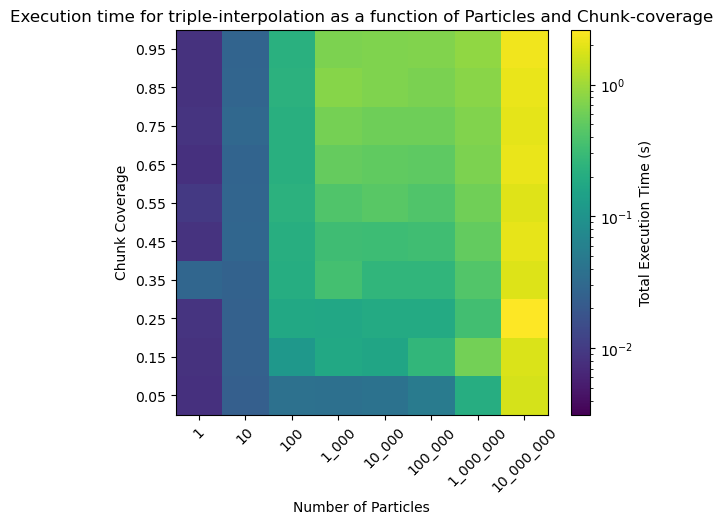

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

function_names = [f.name for f in functions]
k = 1  # Index for TripleInterpolation
ax.pcolormesh(
    range(len(n_particles)),
    range(len(chunk_coverages)),
    total_time[:, :, k],
    shading="auto",
    cmap="viridis",
    norm=LogNorm(vmin=total_time.min(), vmax=total_time.max()),
)

ax.set_xticks(range(len(n_particles)))
ax.set_xticklabels([f"{n:_}" for n in n_particles], rotation=45)
ax.set_yticks(range(len(chunk_coverages)))
ax.set_yticklabels([f"{c:.2f}" for c in chunk_coverages])
fig.colorbar(ax.collections[0], ax=ax, label='Total Execution Time (s)')
ax.set_xlabel('Number of Particles')
ax.set_ylabel('Chunk Coverage')
ax.set_title(f'Execution time for {function_names[k]} as a function of Particles and Chunk-coverage')
plt.show()

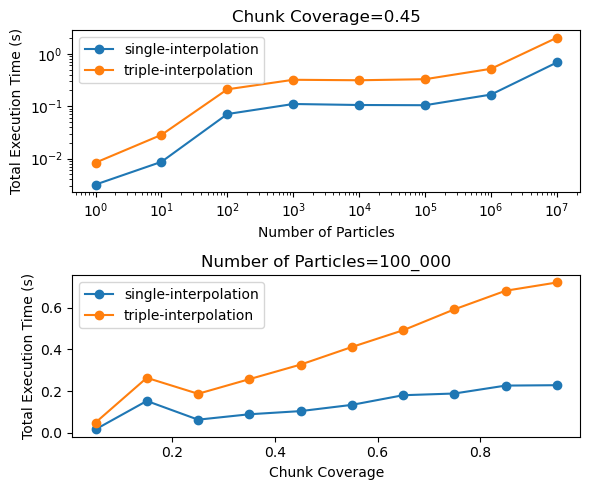

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(6, 5))

i = 4
ax[0].plot(n_particles, total_time[i, :, :], marker='o', label=function_names)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Number of Particles')
ax[0].set_ylabel('Total Execution Time (s)')
ax[0].set_title(f"Chunk Coverage={chunk_coverages[i]:.2f}")
ax[0].legend()

i = 5
ax[1].plot(chunk_coverages, total_time[:, i, :], marker='o', label=function_names)
ax[1].set_xlabel('Chunk Coverage')
ax[1].set_ylabel('Total Execution Time (s)')
ax[1].set_title(f"Number of Particles={n_particles[i]:_}")
ax[1].legend()

plt.tight_layout()
plt.show()